# 1.Package Import

In [50]:
from bmovie_code import gen_table1_subj_info
from pynwb import NWBHDF5IO
from pathlib import Path
import numpy as np
import pandas as pd

from new_code import data_summary, load_data_into_pds, load_data_into_dict, slicer, label, feature, decompose, fusion, new_fusion
from new_code.neural_network import dataset_builder, Trainer, full_model
from new_code.neural_network.evaluation import metrics

import pickle
from scipy.signal import detrend

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import torch

print("MPS:", torch.backends.mps.is_available())
print("CUDA:", torch.cuda.is_available())

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

MPS: True
CUDA: False
Using device: mps


# 2. Global file location (need to specify your own path)

In [18]:
NWB_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files"
BIDS_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/bids_files"

In [19]:
gen_table1_subj_info.main(
    nwb_input_dir=NWB_DIR,
    bids_datadir=BIDS_DIR
)

# 3. Load labels and data

In [20]:
# labels
with open("../assets/annotations/short_faceannots.pkl", "rb") as f:
    face_annots = pickle.load(f)

type(face_annots)
# print(list(face_annots.items())[:10])

path = "../assets/annotations/scenecut_info.csv"
scenecut_info = pd.read_csv(path)

print(scenecut_info.head())

   scene_id  shot_start_fr  shot_start_t  shot_dur_t  location cut_type  \
0       1.0            1.0          0.00        4.72  backyard      cut   
1       1.0          119.0          4.72       10.28  backyard      cut   
2       1.0          376.0         15.00        1.72  backyard      cut   
3       1.0          419.0         16.72        2.36  backyard      cut   
4       1.0          478.0         19.08        2.64  backyard      cut   

   cut_dur_t  cut_dur_fr  
0        0.0           0  
1        0.0           0  
2        0.0           0  
3        0.0           0  
4        0.0           0  


In [21]:
df_face_note = label.build_face_feature_df(face_annots, target_id="Jacky")
print(df_face_note.tail())

        frame_key  frame_idx  movie_time  n_faces  total_face_area  \
9373  frame_11898      11898      475.92        2      35470.00073   
9374  frame_11899      11899      475.96        2      35470.00073   
9375  frame_11900      11900      476.00        2      35470.00073   
9376  frame_11901      11901      476.04        2      35470.00073   
9377  frame_11902      11902      476.08        2      35470.00073   

      max_face_area  Jacky_present  any_front_face dominant_emotion  \
9373   24058.686485              0               1        surprised   
9374   24058.686485              0               1        surprised   
9375   24058.686485              0               1        surprised   
9376   24058.686485              0               1        surprised   
9377   24058.686485              0               1        surprised   

      emo_afraid  emo_angry  emo_happy  emo_neutral  emo_surprised  
9373       False      False      False        False           True  
9374       Fal

## 3.1 Label Check

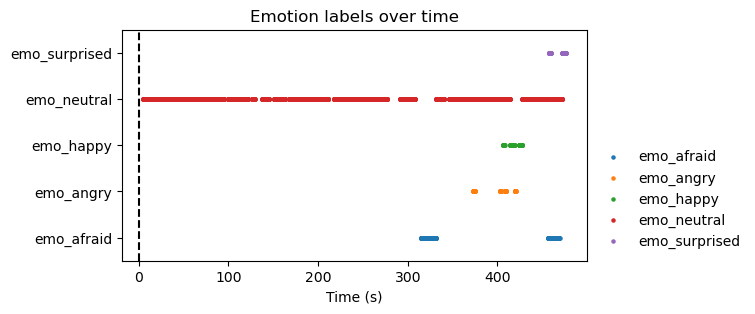

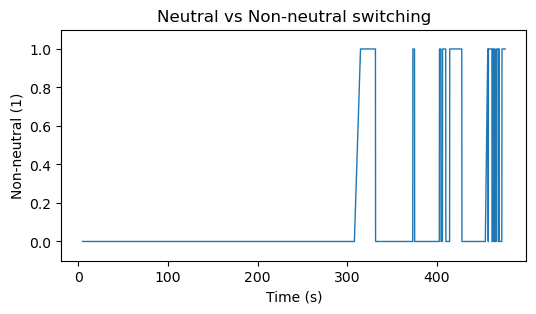

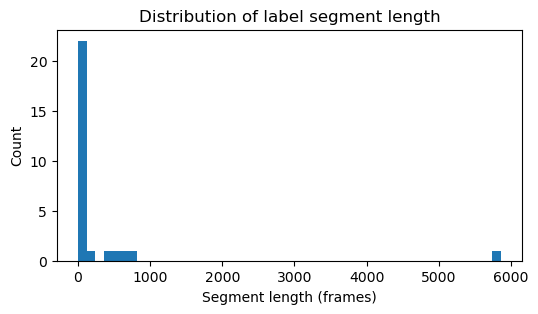

median: 47.0
short (<5 frames): 0.0


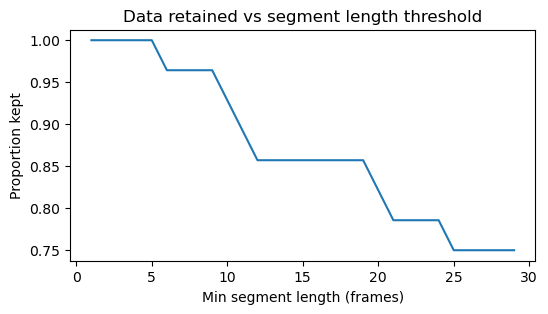

In [22]:
import matplotlib.pyplot as plt

emo_cols = [
    "emo_afraid",
    "emo_angry",
    "emo_happy",
    "emo_neutral",
    "emo_surprised"
]

t = df_face_note["movie_time"].values

# ===================================
# face emotion label check
# ===================================
plt.figure(figsize=(6, 3))

for i, col in enumerate(emo_cols):
    y = df_face_note[col].astype(int) * (i + 1)
    plt.scatter(t, y, s=5, label=col)

plt.axvline(0, color="black", linestyle="--")
plt.yticks(range(1, len(emo_cols)+1), emo_cols)
plt.ylim(0.5, len(emo_cols)+0.5)
plt.xlabel("Time (s)")
plt.title("Emotion labels over time")
plt.legend(bbox_to_anchor=(1.0,0), loc="lower left", frameon=False)
plt.show()

# ===================================
# face emotion switching
# ===================================
is_non_neutral = ~df_face_note["emo_neutral"]

plt.figure(figsize=(6, 3))
plt.plot(t, is_non_neutral.astype(int), linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Non-neutral (1)")
plt.title("Neutral vs Non-neutral switching")
plt.ylim(-0.1, 1.1)
plt.show()

# ===================================
# distribution check
# ===================================
labels = df_face_note["dominant_emotion"].values

segments = []
start = 0

for i in range(1, len(labels)):
    if labels[i] != labels[i-1]:
        segments.append((labels[i-1], start, i-1))
        start = i

segments.append((labels[-1], start, len(labels)-1))

lengths = [end - start + 1 for (_, start, end) in segments]

plt.figure(figsize=(6, 3))
plt.hist(lengths, bins=50)
plt.xlabel("Segment length (frames)")
plt.ylabel("Count")
plt.title("Distribution of label segment length")
plt.show()

print("median:", np.median(lengths))
print("short (<5 frames):", np.mean(np.array(lengths) < 5))

# ===================================
# screen check
# ===================================

lengths = np.array(lengths)

thresholds = np.arange(1, 30)
proportion = [(lengths >= th).mean() for th in thresholds]

plt.figure(figsize=(6, 3))
plt.plot(thresholds, proportion)
plt.xlabel("Min segment length (frames)")
plt.ylabel("Proportion kept")
plt.title("Data retained vs segment length threshold")
plt.show()

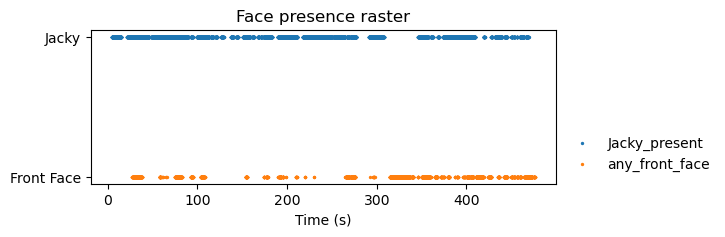

In [23]:
import matplotlib.pyplot as plt

t = df_face_note["movie_time"].values

jacky = df_face_note["Jacky_present"].astype(int).values
front = df_face_note["any_front_face"].astype(int).values

plt.figure(figsize=(6, 2))

plt.scatter(t[jacky == 1], [1]*np.sum(jacky==1), s=2, label="Jacky_present")
plt.scatter(t[front == 1], [0]*np.sum(front==1), s=2, label="any_front_face")

plt.yticks([0, 1], ["Front Face", "Jacky"])
plt.xlabel("Time (s)")
plt.title("Face presence raster")
plt.legend(bbox_to_anchor=(1.0,0), loc="lower left", frameon=False)
plt.show()

In [24]:
nwb_path = load_data_into_pds.find_nwb_file_for_subject(NWB_DIR, "CS41")
print("Using:", nwb_path)

io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
nwb = io.read()

print("\n=== acquisition keys ===")
print(list(nwb.acquisition.keys()))

print("\n=== processing modules ===")
print(list(nwb.processing.keys()))

for mod_name, mod in nwb.processing.items():
    print(f"\n=== processing[{mod_name}] ===")

    for di_name, di in mod.data_interfaces.items():
        print(f"\n--- data_interface: {di_name} ({type(di)}) ---")

        # 情况1：BehavioralTimeSeries / EyeTracking / PupilTracking
        if hasattr(di, "time_series"):
            for ts_name, ts in di.time_series.items():
                data = ts.data
                print(f"  TimeSeries: {ts_name}")
                print(f"    shape: {data.shape}")
                print(f"    dtype: {data.dtype}")

        # 情况2：直接就是 TimeSeries
        elif hasattr(di, "data"):
            data = di.data
            print(f"  direct data:")
            print(f"    shape: {data.shape}")
            print(f"    dtype: {data.dtype}")

        else:
            print("  Unknown structure")

print("\n=== stimulus keys ===")
print(list(getattr(nwb, "stimulus", {}).keys()))

print("\n=== intervals ===")
print(list(getattr(nwb, "intervals", {}).keys()))

io.close()

Using: /Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb

=== acquisition keys ===
['events_ttl', 'experiment_ids']

=== processing modules ===
['behavior', 'ecephys']

=== processing[behavior] ===

--- data_interface: Blink (<class 'pynwb.behavior.BehavioralTimeSeries'>) ---
  TimeSeries: TimeSeries
    shape: (168,)
    dtype: float64

--- data_interface: EyeTracking (<class 'pynwb.behavior.EyeTracking'>) ---
  Unknown structure

--- data_interface: Fixation (<class 'pynwb.behavior.BehavioralTimeSeries'>) ---
  TimeSeries: TimeSeries
    shape: (1577, 4)
    dtype: float64

--- data_interface: PupilTracking (<class 'pynwb.behavior.PupilTracking'>) ---
  TimeSeries: TimeSeries
    shape: (374801,)
    dtype: int64

--- data_interface: Saccade (<class 'pynwb.behavior.BehavioralTimeSeries'>) ---
  TimeSeries: TimeSeries
    shape: (1577, 7)
    dtype: float64

=== processing[ecephys] ===

--- data_interface: LFP_macro (<clas

In [57]:
# sub_nums = [41,]
sub_nums = [41, 42, 43, 44, 47, 48, 49, 51, 53, 54, 55, 56, 57, 58, 60, 62]

filter_config = {
    "lfp_macro": [
        {"type": "bandstop", "low": 58, "high": 62, "order": 4},
        {"type": "bandstop", "low": 118, "high": 122, "order": 4},
        {"type": "bandpass", "low": 0.5, "high": 150, "order": 4},
    ],
    "lfp_micro": [
        {"type": "bandstop", "low": 58, "high": 62, "order": 4},
        {"type": "bandstop", "low": 118, "high": 122, "order": 4},
        {"type": "bandpass", "low": 0.5, "high": 150, "order": 4},
    ],
    "eye_gaze":  {"type": "lowpass",  "high": 20.0, "order": 4},
    "pupil":     {"type": "lowpass",  "high": 10.0, "order": 4},
}

data = load_data_into_dict.load_multimodal_subjects_movie_aligned(
    sub_nums=sub_nums,
    nwb_root=NWB_DIR,
    bids_root=BIDS_DIR,
    max_nwb_samples=2000000,
    b_filter_data=True,
    filter_config=filter_config,
    
    grid_source= "uniform",   # {"movie_frame_time", "uniform", "lfp_raw"}
    grid_dt = 0.004,         # used when grid_source == "uniform"
    uniform_grid_include_baseline = True,

    compute_firing_rate= True,
    firing_rate_bin_width= None,  # if None, infer from t_grid
    compute_lfp_bandpower= True,
    lfp_bandpower_on_raw= True,       # recommended
    bands= None,

    # optional fmri
    load_fmri= False,
    fmri_max_runs= None,
)

print(data[41].keys())
print(data[41]['meta'])
print(data[41]["lfp_macro"].shape, data[41]["eye_gaze"].shape)
# print("n_units:", data[41]["meta"]["n_units"], "firing_rate:", data[41]["firing_rate"].shape)
print("band keys:", list(data[41]["lfp_bandpower"].keys()))
# data[41]["lfp_macro"][:, :5]
x = data[41]["lfp_macro"]
t = data[41]["time_grid"]
print(x.shape, len(t))

[sub 41] t_eye_raw range=(0.000, 749.600)
[sub 41] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb
[sub 41] fs_macro=1000.0, fs_micro=1000.0, fs_eye=499.9999999976126
[sub 41] t_macro_movie range=(-10.000, 753.963)
[sub 41] movieframe_time(frame) range=(0.000, 11970.000)
[sub 41] movieframe_time_sec range=(0.000, 478.800)
[sub 41] t_grid len=190992 source=uniform
[sub 42] t_eye_raw range=(0.001, 813.863)
[sub 42] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS42/sub-CS42_ses-P42CSR1_behavior+ecephys.nwb
[sub 42] fs_macro=1000.0, fs_micro=1000.0, fs_eye=499.9999999976126
[sub 42] t_macro_movie range=(-10.000, 814.068)
[sub 42] movieframe_time(frame) range=(0.000, 11970.000)
[sub 42] movieframe_time_sec range=(0.000, 478.800)
[sub 42] t_grid len=206018 source=uniform
[sub 43] t_eye_raw range=(0.000, 823.604)
[sub 43] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/00062

In [64]:
MODALITY_PCA_DICT = {
    "firing_rate": 5,
    "lfp_micro": 32,
    "lfp_macro": 32,
    "eye_gaze": 5,
    "pupil": 0,
}

data_pca = feature.apply_subjectwise_pca_to_modalities(
    data,
    modality_pca_dict=MODALITY_PCA_DICT,
    copy_data=True,
    fillna_value=0.0,
    store_pca_model=False,
    verbose=True,
)

[pca] sub=41, modality=firing_rate: (190992, 7) -> (190992, 5), explained_var_sum=0.9013
[pca] sub=41, modality=lfp_micro: (190992, 80) -> (190992, 32), explained_var_sum=0.9967
[pca] sub=41, modality=lfp_macro: (190992, 96) -> (190992, 32), explained_var_sum=0.9386
[keep] sub=41, modality=eye_gaze: target_dim >= D (5 >= 2)
[keep] sub=41, modality=pupil: target_dim=0, keep original
[pca] sub=42, modality=firing_rate: (206018, 50) -> (206018, 5), explained_var_sum=0.3156
[pca] sub=42, modality=lfp_micro: (206018, 64) -> (206018, 32), explained_var_sum=0.9853
[pca] sub=42, modality=lfp_macro: (206018, 96) -> (206018, 32), explained_var_sum=0.9519
[keep] sub=42, modality=eye_gaze: target_dim >= D (5 >= 2)
[keep] sub=42, modality=pupil: target_dim=0, keep original
[pca] sub=43, modality=firing_rate: (208468, 32) -> (208468, 5), explained_var_sum=0.5569
[pca] sub=43, modality=lfp_micro: (208468, 80) -> (208468, 32), explained_var_sum=0.9765
[pca] sub=43, modality=lfp_macro: (208468, 96) -> 

In [27]:
eye_data = data_pca[41]["eye_gaze"]
print("movie_time shape:", data[41]["movieframe_time"].shape)
print("eye_gaze shape:", eye_data.shape)
print(eye_data[:5])

movie_time shape: (11971,)
eye_gaze shape: (190992, 2)
[[630.07562256 548.12335205]
 [630.07562256 548.12335205]
 [630.07562256 548.12335205]
 [630.07562256 548.12335205]
 [630.07562256 548.12335205]]


# 4. Face Encoding Model
## 4.1 Feature Engineering

In [65]:
norm_modality_dict = {
    "firing_rate": [True, "max"],
    "lfp_macro": [False, "zscore"],
    "lfp_micro": [False, "zscore"],
    "eye_gaze": [True, "min_max"],
    "pupil": [True, "max"],
}

all_window_data = feature.build_all_subject_window_datasets(
    out=data_pca,
    df_face_note=df_face_note,
    window_size_sec=0.5,          # 500 ms
    stride_sec=0.25,               # 100 ms stride
    start_time=0.0,
    end_time=478.800,
    remove_baseline_windows=True,
    do_baseline_norm=True,
    norm_modality_dict=norm_modality_dict,
    baseline_mode="zscore",
    baseline_start=-10.0,
    baseline_end=0.0,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    use_only_valid_face_frames=True,
    valid_face_mode="front_or_face",
    require_all_modalities_nonempty=False,
    verbose=True,
)

all_window_data_filtered = {}

# filter valid window, face ratio, min_frame
for sub, sub_data in all_window_data.items():
    all_window_data_filtered[sub] = feature.filter_window_dataset(
        sub_data,
        valid_window_only=True,
        min_valid_face_ratio=0.25,
        min_face_frames=5,
        min_non_neutral=None,
        allowed_hard_labels=None,
        require_modalities_nonempty=["firing_rate"],
        verbose=True,
    )

concat_data = feature.concat_subject_window_data(
    all_window_data_filtered,
    subjects=None,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    add_subject_column=True,
    reset_index=True,
    verbose=True,
)

[build] subject 41
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 42
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 43
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 44
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 47
normalized modali

In [66]:
# numeric_label_configs = {
#     "emo_neutral": {
#         "y_col": "emo_neutral",
#         "mode": "binary",
#         "threshold": 0.5,
#     },
#     "jacky_ratio": {
#         "y_col": "jacky_ratio",
#         "mode": "binary",
#         "threshold": 0.5,
#     },
#     "front_face_ratio": {
#         "y_col": "front_face_ratio",
#         "mode": "binary",
#         "threshold": 0.5,
#     },
# }

numeric_label_configs = {
    "emo_neutral": {
        "y_col": "emo_neutral",
        "mode": "continuous",
    },
    "jacky_ratio": {
        "y_col": "jacky_ratio",
        "mode": "continuous",
    },
    "front_face_ratio": {
        "y_col": "front_face_ratio",
        "mode": "continuous",
    },
}

out = dataset_builder.build_train_test_datasets_from_concat_data(
    concat_data=concat_data,
    modality_keys=["lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    # y_labels=["gaze", "pupil"],
    y_labels=["emo_neutral", "jacky_ratio", "front_face_ratio", ],
    # y_labels=["emo_neutral", "jacky_ratio", "front_face_ratio", "gaze", "pupil"],
    sub_col="sub",
    modality_reduce_modes={
        "lfp_macro": "none",
        "lfp_micro": "none",
        "eye_gaze": "none",
        "pupil": "none",
    },
    sequence_label_configs={
        "gaze": {
            "seq_key": "eye_gaze",
            "reduce_mode": "mean",
        },
        "pupil": {
            "seq_key": "pupil",
            "reduce_mode": "last",
        },
    },
    numeric_label_configs=numeric_label_configs,
    test_ratio=0.2,
    batch_size=128,
    random_seed=42,
)

In [45]:
print(out.keys())
print(len(out['samples']))

dict_keys(['dataset', 'train_dataset', 'test_dataset', 'train_loader', 'test_loader', 'samples', 'label_meta', 'modality_keys', 'y_labels'])
24320


# Train with eye decoder

Epoch 001/300 | lr 3.00e-04 | train loss 0.030328 | val loss 0.027106 | best 0.027106 (ep 001) | es 0/10 | improved
Epoch 002/300 | lr 3.00e-04 | train loss 0.025952 | val loss 0.047254 | best 0.027106 (ep 001) | es 1/10
Epoch 003/300 | lr 3.00e-04 | train loss 0.024591 | val loss 0.105417 | best 0.027106 (ep 001) | es 2/10
Epoch 004/300 | lr 3.00e-04 | train loss 0.022552 | val loss 0.114470 | best 0.027106 (ep 001) | es 3/10
Epoch 005/300 | lr 3.00e-04 | train loss 0.021442 | val loss 0.101217 | best 0.027106 (ep 001) | es 4/10 | lr-> 1.50e-04
Epoch 006/300 | lr 1.50e-04 | train loss 0.020116 | val loss 0.103724 | best 0.027106 (ep 001) | es 5/10
Epoch 007/300 | lr 1.50e-04 | train loss 0.019680 | val loss 0.104495 | best 0.027106 (ep 001) | es 6/10
Epoch 008/300 | lr 1.50e-04 | train loss 0.019363 | val loss 0.103490 | best 0.027106 (ep 001) | es 7/10
Epoch 009/300 | lr 1.50e-04 | train loss 0.019166 | val loss 0.094811 | best 0.027106 (ep 001) | es 8/10 | lr-> 7.50e-05
Epoch 010/30

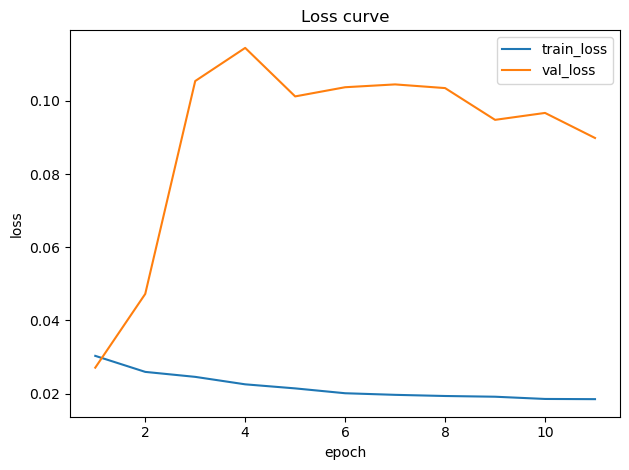

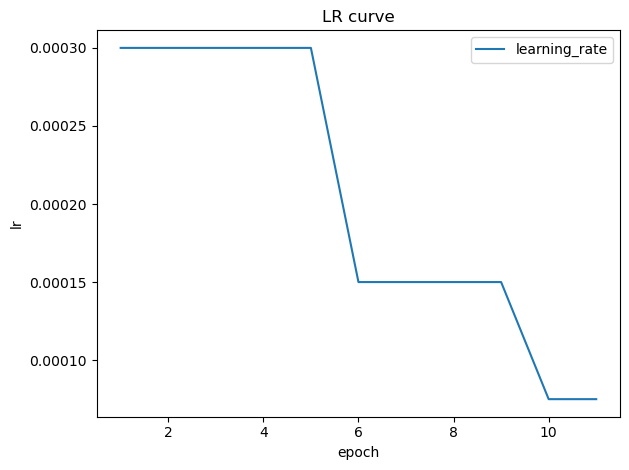

best saved to: best_model.pt
=== Test metrics ===

gaze
  gaze_0
    mae: 0.080618
    mse: 0.010583
    rmse: 0.102874
    r2: 0.052714
  gaze_1
    mae: 0.077312
    mse: 0.008868
    rmse: 0.094170
    r2: 0.026212
  gaze_all
    mae: 0.078965
    mse: 0.009725
    rmse: 0.098618

pupil
  mae: 0.219992
  mse: 0.061875
  rmse: 0.248747
  r2: -0.078220


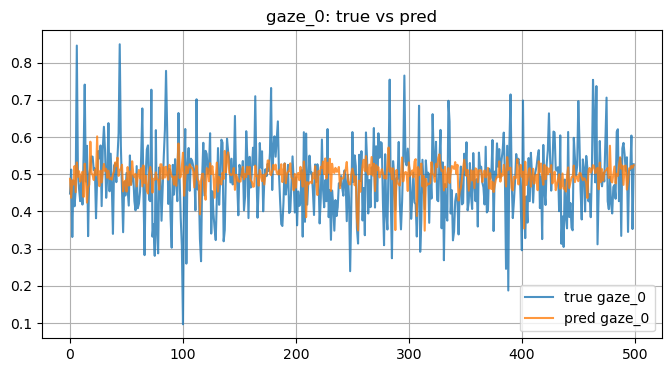

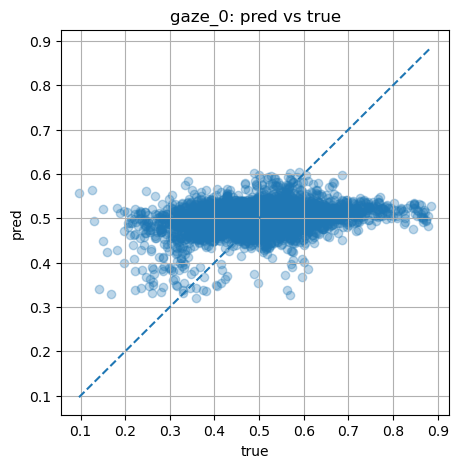

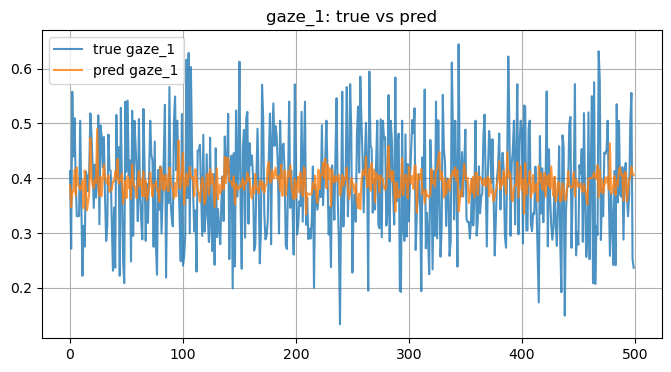

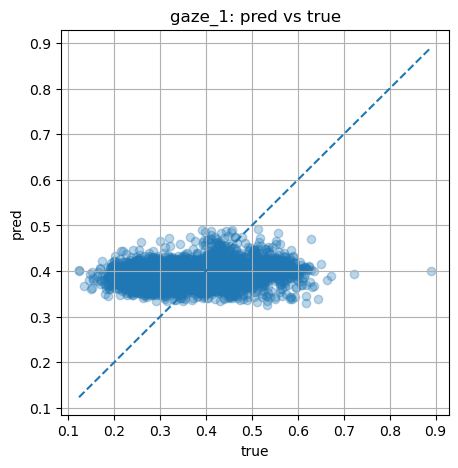

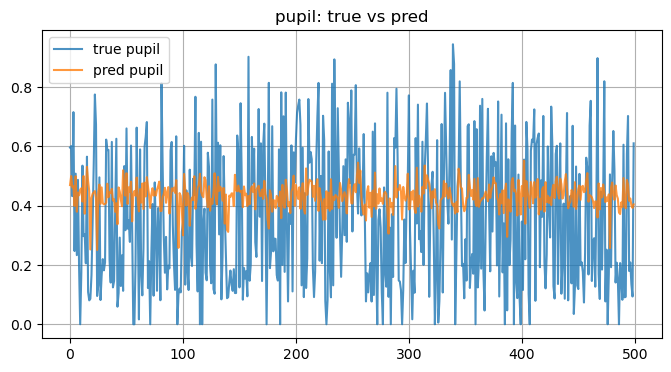

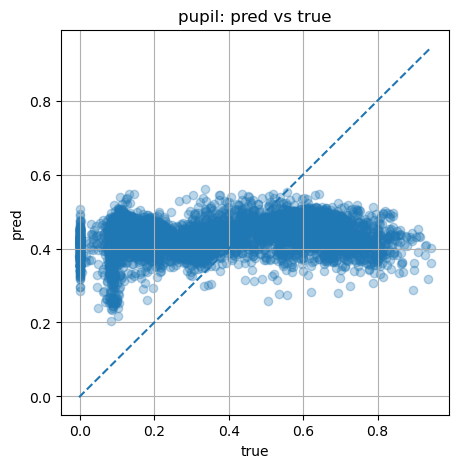

In [69]:
out = dataset_builder.build_train_test_datasets_from_concat_data(
    concat_data=concat_data,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro"],
    y_labels=["gaze", "pupil"],
    # y_labels=["emo_neutral", "jacky_ratio", "front_face_ratio", ],
    # y_labels=["emo_neutral", "jacky_ratio", "front_face_ratio", "gaze", "pupil"],
    sub_col="sub",
    modality_reduce_modes={
        "lfp_macro": "none",
        "lfp_micro": "none",
        "eye_gaze": "none",
        "pupil": "none",
    },
    sequence_label_configs={
        "gaze": {
            "seq_key": "eye_gaze",
            "reduce_mode": "mean",
        },
        "pupil": {
            "seq_key": "pupil",
            "reduce_mode": "mean",
        },
    },
    numeric_label_configs=numeric_label_configs,
    test_ratio=0.2,
    batch_size=128,
    random_seed=42,
)

train_loader = out["train_loader"]
test_loader = out["test_loader"]

model = full_model.MultiModalFusionModel(
    modalities=["firing_rate", "lfp_macro", "lfp_micro"],
    n_temporal_layers=2,
    b_mod_early_fusion=False,
    d_encoder_dim=32,
    d_encoder_hidden=128,
    encoder_time_dilation=1,
    encoder_time_kernel=7,
    b_use_maxpooling_layer=True,
    sequential_model_hidden=64,
    sequential_model_type="transformer",
    sequential_model_layers=2,
    sequential_pooling="attn",
    dropout=0.1,
    outhead="eye_decode",
    label_dim=3,
)

cfg = Trainer.TrainConfig(
    epochs=300,
    batch_size=128,
    lr=3e-4,
    save_path="best_model.pt",
    y_order=["gaze", "pupil"],
    early_stop_patience=10,
)

history, best_path = Trainer.run_training_with_loaders(
    model,
    train_loader,
    test_loader,
    cfg,
    loss="smooth_l1",
    device="cpu",
)
print("best saved to:", best_path)

eval_metrics, out = metrics.evaluate_model(
    model,
    test_loader,
    y_order=["gaze", "pupil"],
    device="cpu",
)

=== Test metrics ===

gaze_x
  mae: 0.081389
  mse: 0.010418
  rmse: 0.102071
  r2: 0.067444

gaze_y
  mae: 0.077383
  mse: 0.008984
  rmse: 0.094784
  r2: 0.013468

pupil
  mae: 0.204108
  mse: 0.057522
  rmse: 0.239837
  r2: 0.073485

gaze_all
  mae: 0.079386
  mse: 0.009701
  rmse: 0.098495


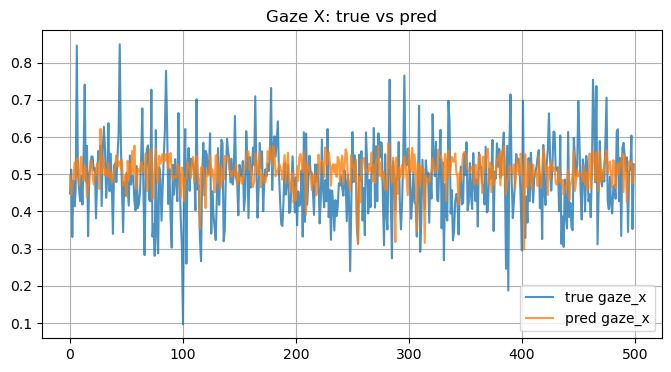

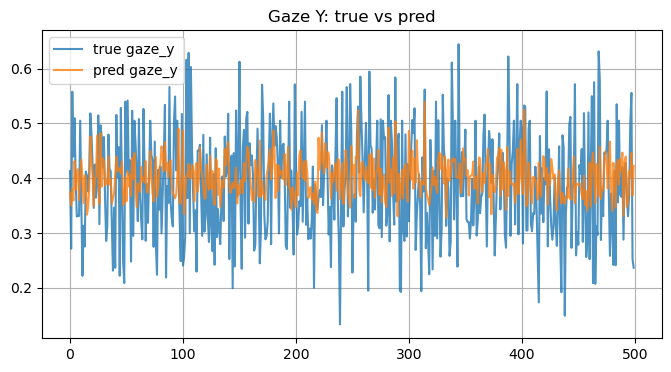

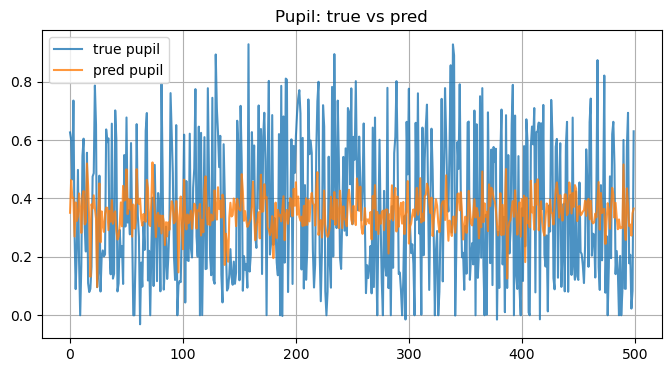

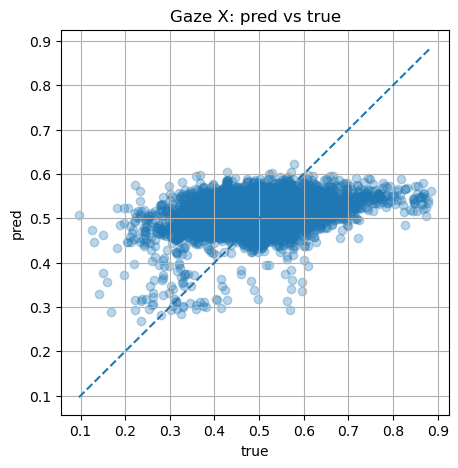

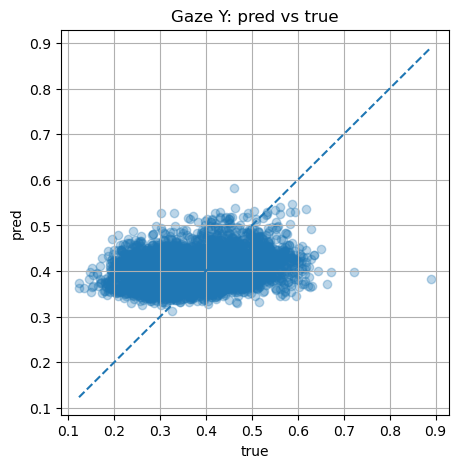

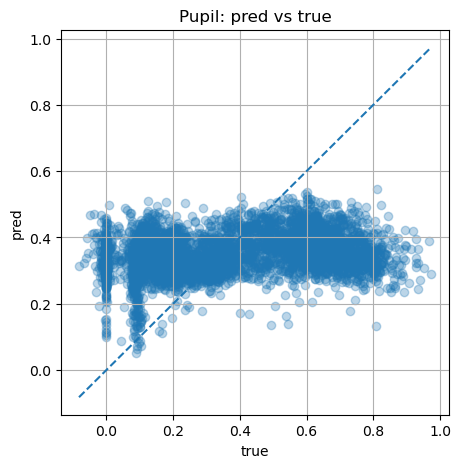

({'gaze_x': {'mae': 0.08138871192932129,
   'mse': 0.01041843555867672,
   'rmse': 0.10207074135541916,
   'r2': 0.0674436092376709},
  'gaze_y': {'mae': 0.07738258689641953,
   'mse': 0.008984007872641087,
   'rmse': 0.09478400647640228,
   'r2': 0.013468146324157715},
  'pupil': {'mae': 0.20410779118537903,
   'mse': 0.057521894574165344,
   'rmse': 0.23983722925186157,
   'r2': 0.07348477840423584},
  'gaze_all': {'mae': 0.07938564568758011,
   'mse': 0.009701221249997616,
   'rmse': 0.09849477559328079}},
 {'y_true': array([[0.44828993, 0.41286942, 0.6261403 ],
         [0.5127634 , 0.27109307, 0.6001797 ],
         [0.33135888, 0.55783975, 0.4653449 ],
         ...,
         [0.4469127 , 0.38713348, 0.09915003],
         [0.38329282, 0.29547918, 0.08475634],
         [0.5105829 , 0.5489882 , 0.10265316]],
        shape=(4864, 3), dtype=float32),
  'y_pred': array([[0.4953205 , 0.37248504, 0.3510505 ],
         [0.44342667, 0.35053295, 0.4631438 ],
         [0.4699515 , 0.38073486,

In [36]:
metrics.evaluate_eye_model(model, test_loader, device="cpu")

## Train 3 face labels

Epoch 001/300 | lr 3.00e-04 | train loss 0.158868 | val loss 0.135810 | best 0.135810 (ep 001) | es 0/20 | improved
Epoch 002/300 | lr 3.00e-04 | train loss 0.139935 | val loss 0.137609 | best 0.135810 (ep 001) | es 1/20
Epoch 003/300 | lr 3.00e-04 | train loss 0.139201 | val loss 0.137234 | best 0.135810 (ep 001) | es 2/20
Epoch 004/300 | lr 3.00e-04 | train loss 0.138588 | val loss 0.140120 | best 0.135810 (ep 001) | es 3/20
Epoch 005/300 | lr 3.00e-04 | train loss 0.138149 | val loss 0.141922 | best 0.135810 (ep 001) | es 4/20 | lr-> 1.50e-04
Epoch 006/300 | lr 1.50e-04 | train loss 0.137601 | val loss 0.148820 | best 0.135810 (ep 001) | es 5/20
Epoch 007/300 | lr 1.50e-04 | train loss 0.137372 | val loss 0.145622 | best 0.135810 (ep 001) | es 6/20
Epoch 008/300 | lr 1.50e-04 | train loss 0.137051 | val loss 0.148925 | best 0.135810 (ep 001) | es 7/20
Epoch 009/300 | lr 1.50e-04 | train loss 0.136929 | val loss 0.145424 | best 0.135810 (ep 001) | es 8/20 | lr-> 7.50e-05
Epoch 010/30

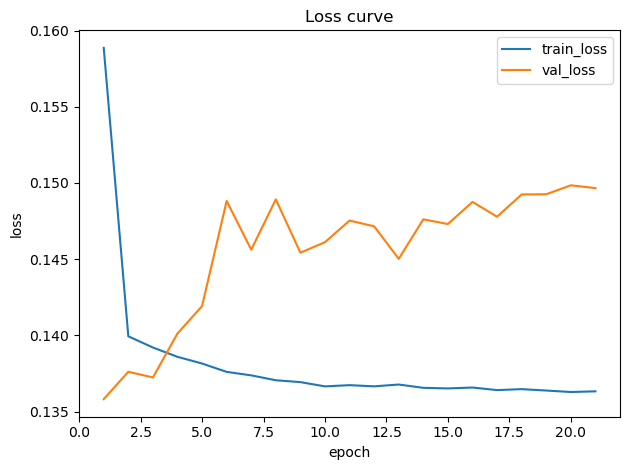

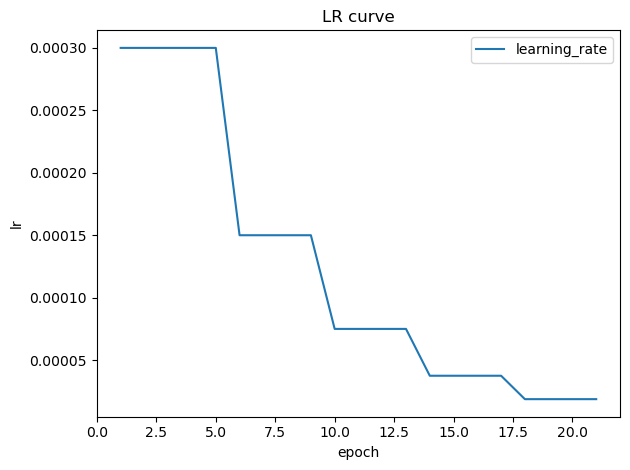

best saved to: best_model.pt


In [ ]:
out = dataset_builder.build_train_test_datasets_from_concat_data(
    concat_data=concat_data,
    modality_keys=["lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    # y_labels=["gaze", "pupil"],
    y_labels=["emo_neutral", "jacky_ratio", "front_face_ratio", ],
    # y_labels=["emo_neutral", "jacky_ratio", "front_face_ratio", "gaze", "pupil"],
    sub_col="sub",
    modality_reduce_modes={
        "lfp_macro": "none",
        "lfp_micro": "none",
        "eye_gaze": "none",
        "pupil": "none",
    },
    sequence_label_configs={
        "gaze": {
            "seq_key": "eye_gaze",
            "reduce_mode": "mean",
        },
        "pupil": {
            "seq_key": "pupil",
            "reduce_mode": "last",
        },
    },
    numeric_label_configs=numeric_label_configs,
    test_ratio=0.2,
    batch_size=128,
    random_seed=42,
)

train_loader = out["train_loader"]
test_loader = out["test_loader"]

model = full_model.MultiModalFusionModel(
    modalities=["lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    n_temporal_layers=2,
    b_mod_early_fusion=False,
    d_encoder_dim=32,
    d_encoder_hidden=128,
    encoder_time_dilation=1,
    encoder_time_kernel=7,
    b_use_maxpooling_layer=True,
    sequential_model_hidden=64,
    sequential_model_type="transformer",
    sequential_model_layers=1,
    sequential_pooling="mean",
    dropout=0.1,
    outhead="fcl",
    label_dim=3,
)

cfg = Trainer.TrainConfig(
    epochs=300,
    batch_size=128,
    lr=3e-4,
    save_path="best_model.pt",
    y_order=["emo_neutral", "jacky_ratio", "front_face_ratio"],
    # y_labels=["emo_neutral", "jacky_ratio", "front_face_ratio", "gaze", "pupil"],
)

history, best_path = Trainer.run_training_with_loaders(
    model,
    train_loader,
    test_loader,
    cfg,
    loss="smooth_l1",
    device="cpu",
)

print("best saved to:", best_path)

eval_metrics, out = metrics.evaluate_model(
    model,
    test_loader,
    y_order=["front_face_ratio"],
    device="cpu",
)

=== Test metrics ===

emo_neutral
  mae: 0.173290
  mse: 0.102839
  rmse: 0.320686
  r2: -0.018284

jacky_ratio
  mae: 0.295438
  mse: 0.164717
  rmse: 0.405853
  r2: -0.020765

front_face_ratio
  mae: 0.383099
  mse: 0.201249
  rmse: 0.448608
  r2: -0.025142


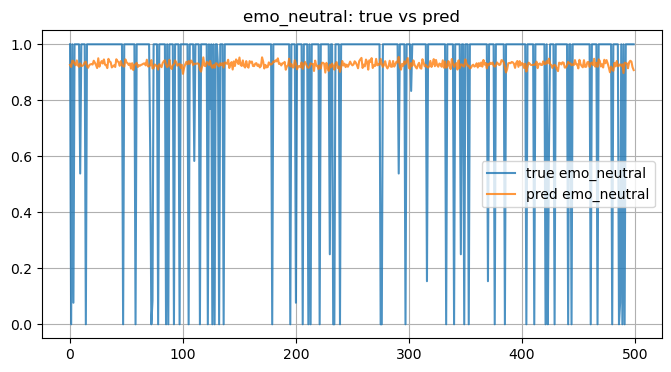

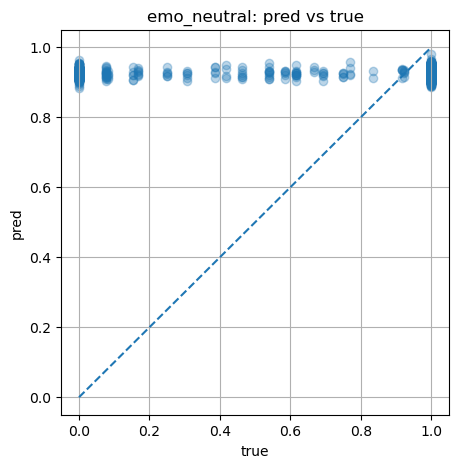

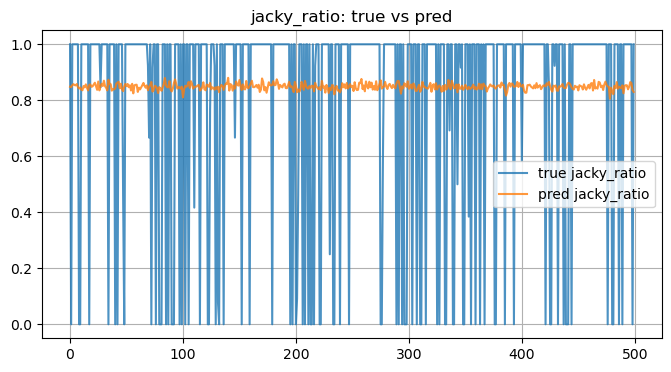

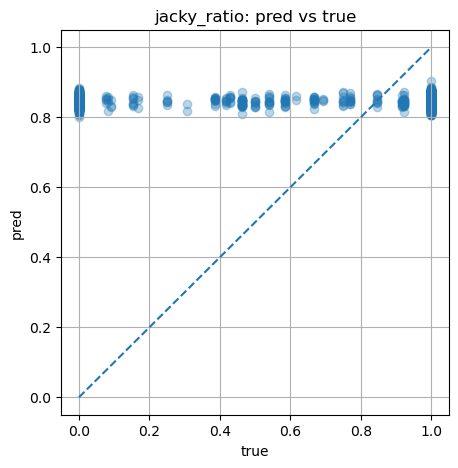

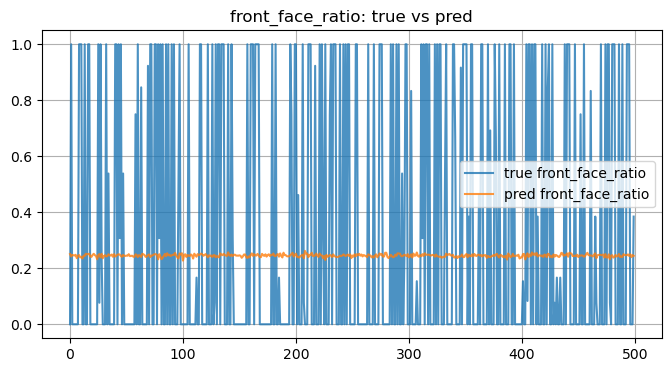

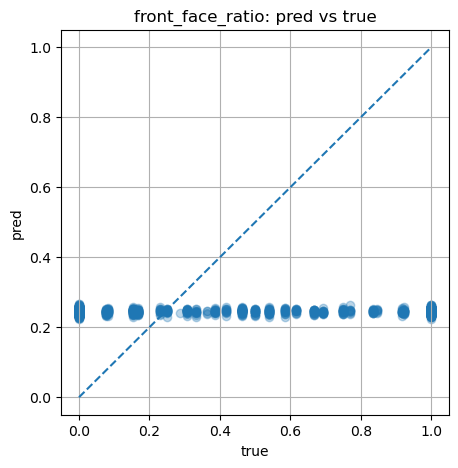

In [48]:
eval_metrics, out = metrics.evaluate_model(
    model,
    test_loader,
    y_order=["emo_neutral", "jacky_ratio", "front_face_ratio"],
    device="cpu",
)

## Train with one-label

Epoch 001/300 | lr 3.00e-04 | train loss 0.185451 | val loss 0.183477 | best 0.183477 (ep 001) | es 0/10 | improved
Epoch 002/300 | lr 3.00e-04 | train loss 0.184315 | val loss 0.183470 | best 0.183477 (ep 001) | es 1/10
Epoch 003/300 | lr 3.00e-04 | train loss 0.183803 | val loss 0.184762 | best 0.183477 (ep 001) | es 2/10
Epoch 004/300 | lr 3.00e-04 | train loss 0.183467 | val loss 0.186801 | best 0.183477 (ep 001) | es 3/10
Epoch 005/300 | lr 3.00e-04 | train loss 0.182931 | val loss 0.189393 | best 0.183477 (ep 001) | es 4/10 | lr-> 1.50e-04
Epoch 006/300 | lr 1.50e-04 | train loss 0.182490 | val loss 0.195732 | best 0.183477 (ep 001) | es 5/10
Epoch 007/300 | lr 1.50e-04 | train loss 0.182590 | val loss 0.197558 | best 0.183477 (ep 001) | es 6/10
Epoch 008/300 | lr 1.50e-04 | train loss 0.181922 | val loss 0.194106 | best 0.183477 (ep 001) | es 7/10
Epoch 009/300 | lr 1.50e-04 | train loss 0.182049 | val loss 0.204612 | best 0.183477 (ep 001) | es 8/10 | lr-> 7.50e-05
Epoch 010/30

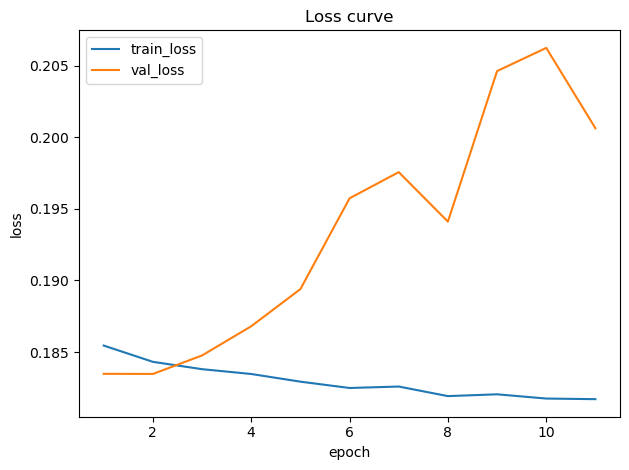

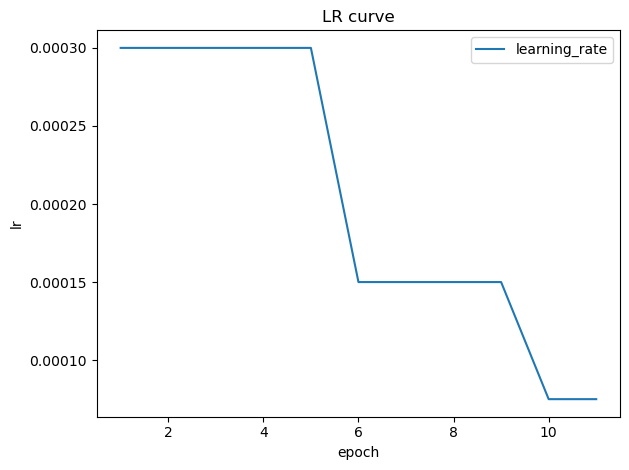

best saved to: best_model.pt
=== Test metrics ===

front_face_ratio
  mae: 0.384244
  mse: 0.200404
  rmse: 0.447666
  r2: -0.020842


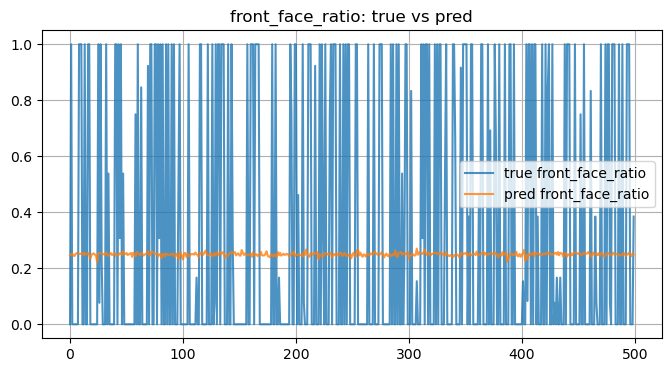

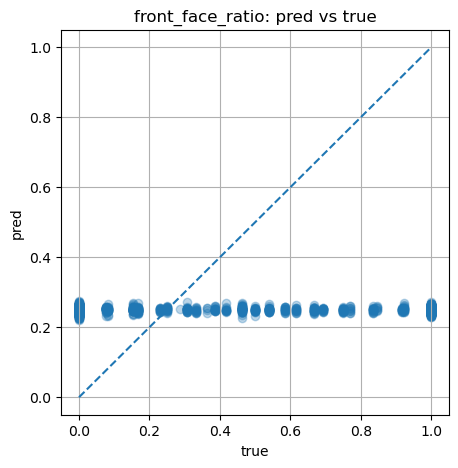

In [52]:
out = dataset_builder.build_train_test_datasets_from_concat_data(
    concat_data=concat_data,
    modality_keys=["lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    # y_labels=["gaze", "pupil"],
    y_labels=["front_face_ratio", ],
    # y_labels=["emo_neutral", "jacky_ratio", "front_face_ratio", "gaze", "pupil"],
    sub_col="sub",
    modality_reduce_modes={
        "lfp_macro": "none",
        "lfp_micro": "none",
        "eye_gaze": "none",
        "pupil": "none",
    },
    sequence_label_configs={
        "gaze": {
            "seq_key": "eye_gaze",
            "reduce_mode": "mean",
        },
        "pupil": {
            "seq_key": "pupil",
            "reduce_mode": "last",
        },
    },
    numeric_label_configs=numeric_label_configs,
    test_ratio=0.2,
    batch_size=128,
    random_seed=42,
)

train_loader = out["train_loader"]
test_loader = out["test_loader"]

model = full_model.MultiModalFusionModel(
    modalities=["lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    n_temporal_layers=2,
    b_mod_early_fusion=False,
    d_encoder_dim=32,
    d_encoder_hidden=128,
    encoder_time_dilation=1,
    encoder_time_kernel=7,
    b_use_maxpooling_layer=True,
    sequential_model_hidden=64,
    sequential_model_type="transformer",
    sequential_model_layers=1,
    sequential_pooling="attn",
    dropout=0.1,
    outhead="fcl",
    label_dim=1,
)

cfg = Trainer.TrainConfig(
    epochs=300,
    batch_size=128,
    lr=3e-4,
    save_path="best_model.pt",
    y_order=["front_face_ratio"],
    early_stop_patience=10,
    # y_labels=["emo_neutral", "jacky_ratio", "front_face_ratio", "gaze", "pupil"],
)

history, best_path = Trainer.run_training_with_loaders(
    model,
    train_loader,
    test_loader,
    cfg,
    loss="smooth_l1",
    device="cpu",
)

print("best saved to:", best_path)

eval_metrics, out = metrics.evaluate_model(
    model,
    test_loader,
    y_order=["front_face_ratio"],
    device="cpu",
)